## Step 0 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 300)
print("pandas:", pd.__version__)

pandas: 2.3.3


## Step 1 — Upload `ico_coffee_long_with_population.csv`

In [2]:
try:
    from google.colab import files
    print("Running in Colab — select ico_coffee_long_with_population.csv...")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab — make sure the file is already in the working directory.")

DATA_PATH = Path("ico_coffee_long_with_population.csv")
assert DATA_PATH.exists(), f"{DATA_PATH} not found — upload it in the cell above."


Not running in Colab — make sure the file is already in the working directory.


## Step 2 — Load and check which metrics Thailand actually has

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df['Metric'].nunique()} metrics total")

thailand = df[df.Country == "Thailand"]
available_metrics = sorted(thailand["Metric"].unique())
print(f"\nMetrics available for Thailand: {available_metrics}")

for m in available_metrics:
    sub = thailand[thailand.Metric == m]
    print(f"  {m:28s} {len(sub):3d} rows, "
          f"{int(sub['Year'].min())}-{int(sub['Year'].max())}")

Loaded 8,640 rows, 8 metrics total

Metrics available for Thailand: ['domestic_consumption_kg', 'export_kg', 'production_kg']
  domestic_consumption_kg       30 rows, 1990-2019
  export_kg                     30 rows, 1990-2019
  production_kg                 30 rows, 1990-2019


## Step 3 — Reshape for plotting

In [4]:
METRIC_LABELS = {
    "production_kg": "Production",
    "domestic_consumption_kg": "Domestic Consumption",
    "export_kg": "Export",
}

plot_df = thailand[thailand.Metric.isin(METRIC_LABELS)].copy()
plot_df["Metric_label"] = plot_df["Metric"].map(METRIC_LABELS)
plot_df["value_million_kg"] = plot_df["value"] / 1e6
plot_df = plot_df.sort_values("Year")
plot_df.head()

,Country,Coffee type,Metric,Year,value,is_imputed,population,Metric_label,value_million_kg
1350,Thailand,Robusta/Arabica,domestic_consumption_kg,1990.0,11280000.0,False,54738329.0,Domestic Consumption,11.28
7290,Thailand,Robusta/Arabica,production_kg,1990.0,45420000.0,False,54738329.0,Production,45.42
2997,Thailand,NaN,export_kg,1990.0,60060000.0,False,54738329.0,Export,60.06
1351,Thailand,Robusta/Arabica,domestic_consumption_kg,1991.0,13200000.0,False,55637434.0,Domestic Consumption,13.20
7291,Thailand,Robusta/Arabica,production_kg,1991.0,88140000.0,False,55637434.0,Production,88.14


## Step 4 — Plot

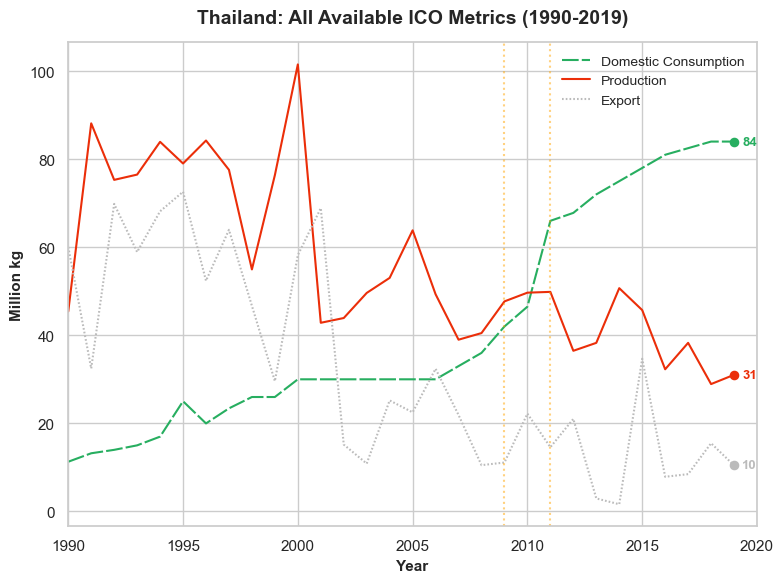

In [5]:
PALETTE = {"Production": "#EB2E09", "Domestic Consumption": "#27ae60", "Export": "#bbbbbb"}
DASHES = {
    "Production": "",              
    "Domestic Consumption": (8, 1.5),  
    "Export": (0.8, 1),               
}

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(data=plot_df, x="Year", y="value_million_kg",
             hue="Metric_label", style="Metric_label",
             ax=ax, linewidth=1.5, palette=PALETTE, dashes=DASHES)
ax.set_title("Thailand: All Available ICO Metrics (1990-2019)", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Year", fontsize=11,fontweight="bold")
ax.set_ylabel("Million kg", fontsize=11,fontweight="bold")
ax.set_xlim(1990, 2020)

ax.legend(loc="upper right", frameon=False, fontsize=10, title="")
xticks = sorted(set(list(range(1990, 2020, 5)) + [2020]))
ax.set_xticks(xticks)
for yr in [2009, 2011]:
    ax.axvline(x=yr, color="orange", linestyle=":", linewidth=1.5,alpha=0.5)
  

for label, color in PALETTE.items():
    last_row = plot_df[plot_df.Metric_label == label].sort_values("Year").iloc[-1]
    ax.scatter([last_row["Year"]], [last_row["value_million_kg"]], color=color, s=35, zorder=5)
    ax.annotate(f"{last_row['value_million_kg']:.0f}", xy=(last_row["Year"], last_row["value_million_kg"]),
                xytext=(6, 0), textcoords="offset points", fontsize=9.5, fontweight="bold",
                color=color, va="center")

plt.tight_layout()
plt.savefig("thailand_all_metrics_Blurredexport.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()



## Step 5 — Download the chart (Colab only)

In [6]:
try:
    from google.colab import files as _colab_files
    _colab_files.download("thailand_all_metrics.png")
except ImportError:
    print(f"Not in Colab — find it locally at: {Path('thailand_all_metrics.png').resolve()}")

Not in Colab — find it locally at: C:\Users\KrissW Laptop\Downloads\graph\Thai all metrics\thailand_all_metrics.png
